In [ ]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0'


from gsmo.hist_features_uni import extract_embeddings
from gsmo.utils import *
from gsmo import GSMO, GSMOConfig
from PIL import Image
import pandas as pd
import numpy as np
import scanpy as sc
import os
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
Image.MAX_IMAGE_PIXELS = None
Image.MAX_IMAGE_PIXELS = None
import torch
import random

seed=100
np.random.seed(seed)
torch.manual_seed(seed)
random.seed(seed)

if torch.cuda.is_available():
    device = 'cuda'
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print("CUDA is available. GPU:", torch.cuda.get_device_name(0))
else:
    device = 'cpu'
    print("CUDA is not available. Using CPU.")


CUDA is available. GPU: NVIDIA GeForce RTX 3090


In [2]:
import os
os.chdir('data/spatial-mux-seq/E13_50um')

In [ ]:
rna = sc.read('scRNA.h5ad')
spatial_coords = rna.obs[['x', 'y']].copy()
spatial_coords = spatial_coords.values
rna_feat = preprocess(rna, modality='rna')

atac = sc.read('atac_seurat_object.h5ad')
atac_feat = atac.obsm['X_lsi']
# preprocess(atac, modality='atac')

H3K27me3 = sc.read('H3K27me3_seurat_object.h5ad')
H3K27me3_feat = H3K27me3.obsm['X_lsi']
# preprocess(H3K27me3, modality='histone')

H3K4me3 = sc.read('H3K4me3_seurat_object.h5ad')
H3K4me3_feat = H3K4me3.obsm['X_lsi']
# preprocess(H3K4me3, modality='histone')


/home/user2/anaconda3/envs/UNI/lib/python3.10/site-packages/scanpy/preprocessing/_scale.py:317: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


"rna = sc.read('scRNA.h5ad')\nspatial_coords = rna.obs[['x', 'y']].copy()\nspatial_coords = spatial_coords.values\n\nrna.var_names_make_unique()\nsc.pp.filter_genes(rna,min_cells=10)\nsc.pp.log1p(rna)\nrna_feat = rna.X\nif scipy.sparse.issparse(rna.X):\n    # 修改后的代码\n    rna_feat = rna.X.toarray() # return adata.X.A\n\natac = sc.read('atac_seurat_object.h5ad')\natac.var_names_make_unique()\nsc.pp.filter_genes(atac,min_cells=10)\nsc.pp.log1p(atac)\natac_feat = atac.X\nif scipy.sparse.issparse(atac.X):\n    # 修改后的代码\n    atac_feat = atac.X.toarray() # return adata.X.A\n    \nH3K4me3 = sc.read('H3K4me3_seurat_object.h5ad')\nH3K4me3.var_names_make_unique()\nsc.pp.filter_genes(H3K4me3,min_cells=10)\nsc.pp.log1p(H3K4me3)\nH3K4me3_feat = H3K4me3.X\nif scipy.sparse.issparse(H3K4me3.X):\n    # 修改后的代码\n    H3K4me3_feat = H3K4me3.X.toarray() \n    \nH3K27me3 = sc.read('H3K27me3_seurat_object.h5ad')\nH3K27me3.var_names_make_unique()\nsc.pp.filter_genes(H3K27me3,min_cells=10)\nsc.pp.log1p(H3K27me3)

In [4]:
print(rna_feat.shape)
print(atac_feat.shape)
print(H3K27me3_feat.shape)
print(H3K4me3_feat.shape)

(2133, 2832)
(2133, 50)
(2133, 50)
(2133, 50)


In [ ]:
#if using a subset of modality-specific terms, the "ind_views" parameter should be a list with values entries to the indices of the modalities to be included, e.g.,  ind_views=[0,2] if including RNA and image features
#if using a subset of interaction terms, the "combs" parameter should be a list of tuples with entries to the indices of the modalities for each interaction, e.g. combs = [(0,1),(0,2)] if including the RNA-protein and RNA-image interaction terms
features_dict = {
        'rna': rna_feat,        # RNA 数据
        'atac': atac_feat,       # ATAC 数据
        'h3k27me3': H3K27me3_feat,    # H3K27me3 数据
        'h3k4me3': H3K4me3_feat    # H3K27ac 数据
    }

# 设置初始权重（可选）
initial_weights = [1.0, 1.0, 1.0, 1.0]  # 与模态数量匹配
cfg = GSMOConfig
model = GSMO(features_dict, spatial_coords=spatial_coords, device=device, cfg=cfg, trainable_weights=False, initial_weights=initial_weights)
model.load_state_dict(torch.load("best_model.pth"))

/home/user2/anaconda3/envs/UNI/lib/python3.10/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


<All keys matched successfully>

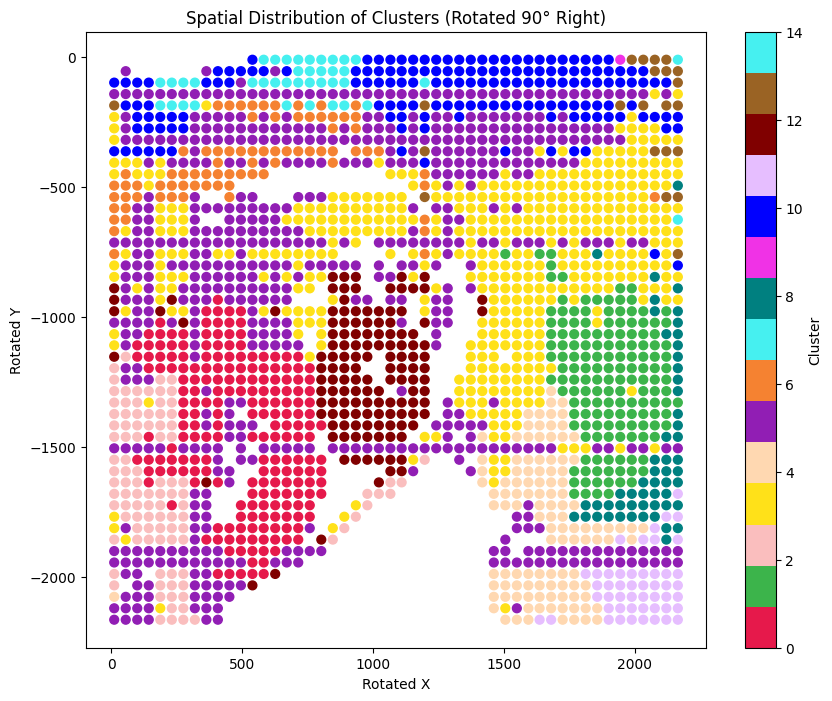

In [ ]:
'''
# 读取数据
rna = sc.read('adata_RNA.h5ad')
atac = sc.read('adata_peaks_normalized.h5ad')

rna_locs = rna.obsm['spatial'] 
assert rna_locs is not None and rna_locs.shape[1] == 2, "RNA 数据缺少位置信息或格式不正确，请检查数据"


clusters = model.cluster(n_clusters=18)
# 将聚类结果添加到位置信息中
rna_locs_df = pd.DataFrame(rna_locs, columns=['x', 'y'])  # 转换为 DataFrame，便于后续操作
rna_locs_df['cluster'] = clusters  # 将聚类标签添加到 DataFrame 中
# im_lowres = plt.imread('tissue_hires_image.png')
scale = 0.051109068
# plot_on_histology(clusters,locs,im_lowres,scale,s=5)

# 绘制空间分布图
plt.figure(figsize=(10, 8))
plt.scatter(rna_locs_df['x'], rna_locs_df['y'], c=rna_locs_df['cluster'], cmap='viridis', s=5)
plt.colorbar(label="Cluster")
plt.title("Spatial Distribution of Clusters")
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.show()'''
from matplotlib.colors import ListedColormap

# 自定义颜色调色板
plot_color = ['#e6194b','#3cb44b', '#fabebe', '#ffe119',  '#ffd8b1', '#911eb4', '#f58231', '#46f0f0', 
              '#008080', '#f032e6', '#0000ff', '#e6beff', '#800000', '#9a6324', '#46f0f0', '#aaffc3', '#808000', 
              '#000075', '#000000', '#808080', '#ffffff', '#fffac8', '#D1D1D1']   # '#ffe119'

# 读取数据
rna = sc.read('scRNA.h5ad')

# print(rna.obs)

assert 'x' in rna.obs.columns and 'y' in rna.obs.columns, "RNA 数据缺少空间坐标，或格式不正确，请检查数据"

# 获取空间坐标
rna_locs = rna.obs[['x', 'y']].copy()


# rna_locs = rna.obsm['spatial'] 
assert rna_locs is not None and rna_locs.shape[1] == 2, "RNA 数据缺少位置信息或格式不正确，请检查数据"

# 聚类结果
clusters = model.cluster_kmeans(n_clusters=15)
# 将聚类结果添加到位置信息中
rna_locs_df = pd.DataFrame(rna_locs, columns=['x', 'y'])  # 转换为 DataFrame，便于后续操作
rna_locs_df['cluster'] = clusters  # 将聚类标签添加到 DataFrame 中

# 聚类数目
num_clusters = len(np.unique(clusters))

# 检查聚类数是否超过了自定义调色板的颜色数
if num_clusters > len(plot_color):
    raise ValueError(f"聚类数目 {num_clusters} 超过了自定义调色板中可用的颜色数 {len(plot_color)}。")

# 创建一个自定义的离散颜色调色板
cmap = ListedColormap(plot_color[:num_clusters])

rna_locs_df['x_rot'] = rna_locs_df['y']
rna_locs_df['y_rot'] = -rna_locs_df['x']

# 绘制空间分布图
plt.figure(figsize=(10, 8))
scatter = plt.scatter(rna_locs_df['x_rot'], rna_locs_df['y_rot'], c=rna_locs_df['cluster'], cmap=cmap, s=40)
plt.colorbar(scatter, label="Cluster")
plt.title("Spatial Distribution of Clusters (Rotated 90° Right)")
plt.xlabel('Rotated X')
plt.ylabel('Rotated Y')
# plt.gca().invert_yaxis()  # 如需左上为原点，可保留
plt.show()



In [9]:
from sklearn.metrics import pairwise_distances
import numpy as np
from tqdm import tqdm

def compute_jaccard_similarity(Z_m, Z_e, k=50):
    """
    Z_m: 单一模态的 feature 表示，例如 RNA (n_spots, d1)
    Z_e: 融合后的 embedding 表示 (n_spots, d2)
    k: 邻居个数，默认 50
    """
    dist_m = pairwise_distances(Z_m)
    dist_e = pairwise_distances(Z_e)
    
    n = Z_m.shape[0]
    jaccard_scores = []

    for i in tqdm(range(n), desc="Calculating Jaccard similarities"):
        neighbors_m = set(np.argsort(dist_m[i])[1:k+1])  # exclude self
        neighbors_e = set(np.argsort(dist_e[i])[1:k+1])
        intersection = len(neighbors_m & neighbors_e)
        union = len(neighbors_m | neighbors_e)
        jaccard = intersection / union if union > 0 else 0.0
        jaccard_scores.append(jaccard)

    return np.array(jaccard_scores), np.mean(jaccard_scores)


import squidpy as sq
import scanpy as sc
import pandas as pd
import numpy as np

def compute_morans_I(labels, spatial_coords, label_name="cluster_label"):
    """
    labels: 聚类结果数组 (n_spots,)
    spatial_coords: 空间坐标 (n_spots, 2)
    """
    # 创建 AnnData，建议用已有 rna 结构替代
    adata = sc.AnnData(X=np.zeros((len(labels), 1)))  # dummy
    adata.obs[label_name] = pd.Categorical([str(x) for x in labels])
    adata.obsm['spatial'] = spatial_coords.astype(float)

    # 构建邻接图
    sq.gr.spatial_neighbors(adata, coord_type="generic", n_neighs=6)

    # 计算 Moran's I 分数（注意指定 attr="obs"）
    sq.gr.spatial_autocorr(adata, mode="moran", genes=label_name, attr="obs")

    # 正确地从 dataframe 中提取
    moran_result = adata.uns["moranI"].loc[label_name, "I"]
    return moran_result




/home/user2/anaconda3/envs/UNI/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(


In [10]:
# 假设你已经有了：
# rna_features: shape (n, d1)
# fused_embeddings: shape (n, d2)
# cluster_labels: shape (n,)
# spatial_coords: shape (n, 2)
fused_embeddings = model.get_embeddings()


# 1. Jaccard
jaccard_all, jaccard_mean = compute_jaccard_similarity(rna_feat, fused_embeddings, k=50)
print(f"Mean Jaccard RNA Similarity: {jaccard_mean:.4f}")

jaccard_all, jaccard_mean = compute_jaccard_similarity(atac_feat, fused_embeddings, k=50)
print(f"Mean Jaccard atac Similarity: {jaccard_mean:.4f}")

jaccard_all, jaccard_mean = compute_jaccard_similarity(H3K27me3_feat, fused_embeddings, k=50)
print(f"Mean Jaccard H3K27me3 Similarity: {jaccard_mean:.4f}")

jaccard_all, jaccard_mean = compute_jaccard_similarity(H3K4me3_feat, fused_embeddings, k=50)
print(f"Mean Jaccard H3K4me3 Similarity: {jaccard_mean:.4f}")


cluster_labels = model.cluster_kmeans(n_clusters=15)
morans_I = compute_morans_I(cluster_labels, spatial_coords)
print(f"Moran's I score: {morans_I:.4f}")



Calculating Jaccard similarities: 100%|██████████| 2133/2133 [00:00<00:00, 6772.32it/s]


Mean Jaccard RNA Similarity: 0.0413


Calculating Jaccard similarities: 100%|██████████| 2133/2133 [00:00<00:00, 6660.06it/s]


Mean Jaccard atac Similarity: 0.2271


Calculating Jaccard similarities: 100%|██████████| 2133/2133 [00:00<00:00, 6701.54it/s]


Mean Jaccard H3K27me3 Similarity: 0.1565


Calculating Jaccard similarities: 100%|██████████| 2133/2133 [00:00<00:00, 6692.79it/s]


Mean Jaccard H3K4me3 Similarity: 0.1336
Moran's I score: 0.7018


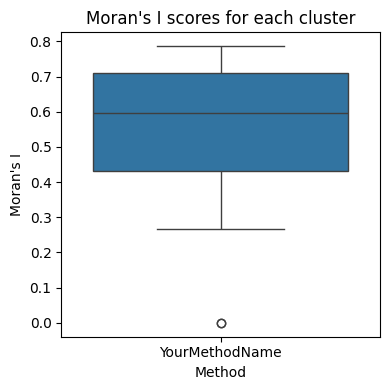

   cluster   moran_I          method
0        0  0.767514  YourMethodName
1        1  0.786591  YourMethodName
2        2  0.691425  YourMethodName
3        3  0.603550  YourMethodName
4        4  0.694083  YourMethodName
5        5  0.413493  YourMethodName
6        6  0.457193  YourMethodName
7        7  0.452173  YourMethodName
8        8  0.554473  YourMethodName
9        9 -0.000235  YourMethodName
10      10  0.595517  YourMethodName
11      11  0.729096  YourMethodName
12      12  0.729215  YourMethodName
13      13  0.266174  YourMethodName
14      14 -0.000156  YourMethodName


In [11]:
import squidpy as sq
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def compute_morans_I_per_method(labels, spatial_coords, method_name="MethodA"):
    """
    计算每个 cluster 的 Moran's I，返回所有 cluster 的分数并将所有分数作为一个 boxplot。
    
    参数：
        labels: 聚类标签数组，形状为 (n_spots,)
        spatial_coords: 空间坐标，形状为 (n_spots, 2)
        method_name: 当前方法的名字，用于 boxplot 标识

    返回：
        df_moran: DataFrame，包含每个 cluster 的 Moran’s I 分数
    """
    adata = sc.AnnData(X=np.zeros((len(labels), 1)))
    adata.obs["cluster_label"] = pd.Categorical([str(x) for x in labels])
    adata.obsm['spatial'] = spatial_coords.astype(float)

    # 构建空间邻接图
    sq.gr.spatial_neighbors(adata, coord_type="generic", n_neighs=6)

    moran_scores = []
    unique_labels = np.unique(labels)

    for label in unique_labels:
        binary_vector = (labels == label).astype(int)
        adata.obs["tmp_binary"] = binary_vector

        sq.gr.spatial_autocorr(adata, mode="moran", genes="tmp_binary", attr="obs")
        I_score = adata.uns["moranI"].loc["tmp_binary", "I"]
        moran_scores.append({
            "cluster": str(label),
            "moran_I": I_score,
            "method": method_name
        })

    df_moran = pd.DataFrame(moran_scores)

    # 绘制一个箱线图（只一个box）
    plt.figure(figsize=(4, 4))
    sns.boxplot(data=df_moran, x="method", y="moran_I")
    plt.title("Moran's I scores for each cluster")
    plt.ylabel("Moran's I")
    plt.xlabel("Method")
    plt.tight_layout()
    plt.show()

    return df_moran

morans_I_df = compute_morans_I_per_method(cluster_labels, spatial_coords, method_name="YourMethodName")
print(morans_I_df)
